# Análisis SparkSQL — Dataset Yelp

**Proyecto Final Big Data**

---

## Configuración inicial

In [1]:
%matplotlib inline
import os
import time
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

load_dotenv()

True

In [2]:
BASE_DIR = (
    os.path.abspath(os.path.join(os.getcwd(), '..')) 
    if os.path.basename(os.getcwd()) == 'analytics'
    else os.getcwd()
)
FILTERED = os.path.join(BASE_DIR, 'data', 'filtered_trimmed')
GRAFICOS = os.path.join(BASE_DIR, 'graficos')
os.makedirs(GRAFICOS, exist_ok=True)

spark = SparkSession.builder \
    .appName('YelpBigData-Notebook') \
    .master('local[*]') \
    .config('spark.driver.memory', '4g') \
    .config('spark.sql.shuffle.partitions', '8') \
    .config('spark.sql.adaptive.enabled', 'true') \
    .config('spark.sql.adaptive.coalescePartitions.enabled', 'true') \
    .config(
        'spark.jars.packages',
        'org.mongodb.spark:mongo-spark-connector_2.13:10.4.0,'
        'org.postgresql:postgresql:42.7.3',
    ) \
    .getOrCreate()

spark.sparkContext.setLogLevel('WARN')
print('SparkSession lista — versión:', spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/15 19:09:22 WARN Utils: Your hostname, Bridge, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/04/15 19:09:22 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
:: loading settings :: url = jar:file:/home/tux/big-data-project/.venv/lib/python3.14/site-packages/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /home/tux/.ivy2.5.2/cache
The jars for the packages stored in: /home/tux/.ivy2.5.2/jars
org.mongodb.spark#mongo-spark-connector_2.13 added as a dependency
org.postgresql#postgresql added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-d15bbbf7-2cc5-4a21-a4bb-0d2067f41077;1.0
	confs: [default]
	found org.mongodb.spark#mongo-spark-connector_2.13;10.4.0 in central
	found org.mongodb#mongodb-driver-sync;5.1.4 in central
	[5.1.4] org.mongodb#mongodb-driver

SparkSession lista — versión: 4.1.1


## Carga de las vistas


| Función | Fuente |
|---|---|
| `cargar_vistas_local()` | `data/filtered_trimmed/` |
| `cargar_vistas_clusters()` | CockroachDB · Aiven · MongoDB Atlas |

In [ ]:
def cargar_vistas_local() -> None:
    """Lee los 5 JSON filtrados y los registra como vistas temporales SparkSQL."""
    print('Cargando archivos JSON desde data/filtered_trimmed/ ...')
    t0 = time.time()

    spark.read.json(f'{FILTERED}/yelp_academic_dataset_business.json') \
         .createOrReplaceTempView('business')

    spark.read.json(f'{FILTERED}/yelp_academic_dataset_review.json') \
         .createOrReplaceTempView('reviews')

    spark.read.json(f'{FILTERED}/yelp_academic_dataset_tip.json') \
         .createOrReplaceTempView('tips')

    spark.read.json(f'{FILTERED}/yelp_academic_dataset_user.json') \
         .createOrReplaceTempView('users')

    df_checkins_raw = spark.read.json(f'{FILTERED}/yelp_academic_dataset_checkin.json')
    df_checkins_raw \
        .withColumn('checkin_ts', F.explode(F.split(F.col('date'), ', '))) \
        .select(
            F.col('business_id'),
            F.col('checkin_ts').cast('timestamp').alias('checkin_ts'),
        ) \
        .createOrReplaceTempView('checkins')

    print(f'Vistas listas en {time.time() - t0:.1f}s')

In [ ]:
def cargar_vistas_clusters() -> None:
    """Lee las 5 tablas desde los clusters en la nube y las registra como vistas temporales."""
    from urllib.parse import urlparse

    print('Cargando datos desde los clusters en la nube ...')
    t0 = time.time()

    # MongoDB Atlas — business (cluster #1)
    atlas_business = os.getenv('ATLAS_URI_BUSINESS_READ')
    spark.read.format('mongodb') \
        .option('connection.uri', atlas_business) \
        .option('database', 'yelp') \
        .option('collection', 'business') \
        .load() \
        .createOrReplaceTempView('business')
    print('  [OK] business  → vista registrada')

    # MongoDB Atlas — tips (cluster #2)
    atlas_tips = os.getenv('ATLAS_URI_TIPS_READ')
    spark.read.format('mongodb') \
        .option('connection.uri', atlas_tips) \
        .option('database', 'yelp') \
        .option('collection', 'tips') \
        .load() \
        .createOrReplaceTempView('tips')
    print('  [OK] tips      → vista registrada')

    # MongoDB Atlas — checkins (cluster #3)
    atlas_checkins = os.getenv('ATLAS_URI_CHECKINS_READ')
    spark.read.format('mongodb') \
        .option('connection.uri', atlas_checkins) \
        .option('database', 'yelp') \
        .option('collection', 'checkins') \
        .load() \
        .withColumn('checkin_ts', F.explode(F.split(F.col('date'), ', '))) \
        .select(
            F.col('business_id'),
            F.col('checkin_ts').cast('timestamp').alias('checkin_ts'),
        ) \
        .createOrReplaceTempView('checkins')
    print('  [OK] checkins  → vista registrada')

    # Aiven PostgreSQL — reviews (JDBC)
    aiven_conn = os.getenv('AIVEN_CONNECTION_READ')
    aiven_cert = os.getenv('AIVEN_SSL_CERT', '')
    aiven_p    = urlparse(aiven_conn)
    if aiven_cert:
        aiven_jdbc = (f'jdbc:postgresql://{aiven_p.hostname}:{aiven_p.port}'
                      f'{aiven_p.path}?sslmode=verify-ca&sslrootcert={os.path.expanduser(aiven_cert)}')
    else:
        aiven_jdbc = (f'jdbc:postgresql://{aiven_p.hostname}:{aiven_p.port}'
                      f'{aiven_p.path}?sslmode=require')
    spark.read.format('jdbc') \
        .option('url', aiven_jdbc) \
        .option('dbtable', 'reviews') \
        .option('driver', 'org.postgresql.Driver') \
        .option('user', aiven_p.username) \
        .option('password', aiven_p.password) \
        .load() \
        .createOrReplaceTempView('reviews')
    print('  [OK] reviews   → vista registrada')

    # CockroachDB — users
    crdb_conn = os.getenv('CRDB_CONNECTION_READ')
    crdb_cert = os.path.expanduser(os.getenv('CRDB_SSL_CERT', '~/.postgresql/root.crt'))
    crdb_p    = urlparse(crdb_conn)
    crdb_jdbc = (f'jdbc:postgresql://{crdb_p.hostname}:{crdb_p.port}'
                 f'{crdb_p.path}?sslmode=verify-full&sslrootcert={crdb_cert}')
    spark.read.format('jdbc') \
        .option('url', crdb_jdbc) \
        .option('dbtable', 'users') \
        .option('driver', 'org.postgresql.Driver') \
        .option('user', crdb_p.username) \
        .option('password', crdb_p.password) \
        .load() \
        .createOrReplaceTempView('users')
    print('  [OK] users     → vista registrada')

    print(f'\nVistas listas en {time.time() - t0:.1f}s')

In [4]:
# cargar_vistas_local()
cargar_vistas_clusters()

Cargando datos desde los clusters en la nube ...
  [OK] business  → vista registrada
  [OK] tips      → vista registrada
  [OK] checkins  → vista registrada
  [OK] reviews   → vista registrada
  [OK] users     → vista registrada

Vistas listas en 14.1s


---
## Q01 — Índice de oportunidad de mercado por ciudad

**Pregunta ejecutiva:** ¿Qué ciudades combinan calidad, demanda y viabilidad?  
**Fuentes:** `business`  

In [ ]:
df = spark.sql("""
    SELECT
        b.city, b.state,
        COUNT(*)                                              AS total_negocios,
        ROUND(AVG(b.stars), 2)                                AS avg_stars,
        ROUND(SUM(b.is_open) / COUNT(*) * 100, 1)             AS pct_abiertos,
        SUM(b.review_count)                                   AS total_reviews,
        ROUND(
            AVG(b.stars)
            * (SUM(b.is_open) / COUNT(*))
            * LOG(SUM(b.review_count) + 1),
            3
        ) AS market_score
    FROM business b
    GROUP BY b.city, b.state
    HAVING COUNT(*) >= 30
    ORDER BY market_score DESC
    LIMIT 20
""")
df.show(20, truncate=False)

pdf = df.toPandas()
sizes = (pdf['total_reviews'] / pdf['total_reviews'].max() * 800) + 50

fig, ax = plt.subplots(figsize=(11, 7))
scatter = ax.scatter(
    pdf['avg_stars'], pdf['pct_abiertos'],
    s=sizes, alpha=0.7,
    c=pdf['market_score'], cmap='viridis',
    edgecolors='black', linewidths=0.4,
)
plt.colorbar(scatter, ax=ax, label='Market Score')
for _, row in pdf.iterrows():
    ax.annotate(
        f"{row['city']}, {row['state']}",
        (row['avg_stars'], row['pct_abiertos']),
        fontsize=7, ha='left', va='bottom', xytext=(3, 3), textcoords='offset points',
    )
ax.set_title('Q01 — Índice de oportunidad de mercado (top-20 ciudades)', pad=12)
ax.set_xlabel('Rating promedio (avg_stars)')
ax.set_ylabel('% de negocios aún abiertos')
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(GRAFICOS, 'q01_oportunidad_mercado_ciudad.png'), dpi=150)
plt.show()

---
## Q02 — Franjas horarias y tráfico de check-ins

**Pregunta ejecutiva:** ¿En qué franja del día concentran más visitas los negocios más populares por ciudad?  
**Fuentes:** `checkins` + `business`  

In [ ]:
df = spark.sql("""
    WITH CheckinMoments AS (
        SELECT
            business_id,
            CASE
                WHEN EXTRACT(HOUR FROM checkin_ts) BETWEEN 6  AND 11 THEN 'Morning (6-12)'
                WHEN EXTRACT(HOUR FROM checkin_ts) BETWEEN 12 AND 17 THEN 'Afternoon (12-18)'
                WHEN EXTRACT(HOUR FROM checkin_ts) BETWEEN 18 AND 23 THEN 'Evening (18-24)'
                ELSE 'Night/Early Morning (0-6)'
            END AS day_segment
        FROM checkins
    ),
    BusinessTraffic AS (
        SELECT b.city, b.name, cm.day_segment, COUNT(*) AS checkin_count
        FROM CheckinMoments cm
        JOIN business b ON cm.business_id = b.business_id
        GROUP BY b.city, b.name, cm.day_segment
    ),
    RankedTraffic AS (
        SELECT city, name, day_segment, checkin_count,
               RANK() OVER (PARTITION BY city, day_segment ORDER BY checkin_count DESC) AS traffic_rank
        FROM BusinessTraffic
    )
    SELECT city, day_segment, name, checkin_count
    FROM RankedTraffic
    WHERE traffic_rank <= 3
      AND city IN ('Philadelphia', 'Tampa', 'Tucson', 'Nashville')
    ORDER BY city ASC, checkin_count DESC
""")
df.show(40, truncate=False)

pdf = df.toPandas()
plt.figure(figsize=(15, 8))
sns.barplot(data=pdf, x='checkin_count', y='day_segment', hue='city', errorbar=None)
plt.title('Check-ins Totales por Franja Horaria y Ciudad (Top 3 Negocios)')
plt.xlabel('Volumen de Check-ins')
plt.ylabel('Franja Horaria')
plt.legend(title='Ciudad', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(GRAFICOS, 'q02_franjas_horarias_trafico.png'), dpi=150)
plt.show()

---
## Q03 — Categorías mejor valoradas con volumen significativo

**Pregunta ejecutiva:** ¿Qué categorías de negocio mantienen las mejores calificaciones promedio con una cantidad relevante de reseñas?  
**Fuentes:** `business` + `reviews`  

In [ ]:
df = spark.sql("""
    WITH categories_expanded AS (
        SELECT b.business_id, TRIM(cat) AS category
        FROM business b
        LATERAL VIEW explode(split(b.categories, ', ')) c AS cat
        WHERE b.categories IS NOT NULL
    ),
    review_base AS (
        SELECT c.category, r.stars
        FROM reviews r
        JOIN categories_expanded c ON r.business_id = c.business_id
    )
    SELECT
        category,
        COUNT(*) AS total_reviews,
        ROUND(AVG(stars), 2) AS avg_stars,
        ROUND(STDDEV_POP(stars), 2) AS stddev_stars
    FROM review_base
    GROUP BY category
    HAVING COUNT(*) >= 1000
    ORDER BY avg_stars DESC, total_reviews DESC
    LIMIT 15
""")
df.show(15, truncate=False)

pdf = df.toPandas()
plt.figure(figsize=(12, 7))
plt.barh(pdf['category'], pdf['avg_stars'])
plt.gca().invert_yaxis()
plt.title('Q03 — Top 15 categorías mejor valoradas con volumen significativo')
plt.xlabel('Promedio de estrellas')
plt.ylabel('Categoría')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(GRAFICOS, 'q03_categorias_mejor_valoradas.png'), dpi=150)
plt.show()

---
## Q04 — Precio vs. Rating promedio por categoría

**Pregunta ejecutiva:** ¿Qué categorías tienen mejor rating según su nivel de precio?  
**Fuentes:** `business`  

In [ ]:
df = spark.sql("""
    SELECT
        TRIM(cat.category)                         AS categoria,
        b.attributes.RestaurantsPriceRange2        AS rango_precio,
        ROUND(AVG(b.stars), 2)                     AS avg_rating,
        COUNT(*)                                   AS total_negocios
    FROM business b
    LATERAL VIEW EXPLODE(SPLIT(b.categories, ',')) cat AS category
    WHERE b.attributes.RestaurantsPriceRange2 IS NOT NULL
      AND b.is_open = 1
    GROUP BY TRIM(cat.category), b.attributes.RestaurantsPriceRange2
    HAVING COUNT(*) >= 30
    ORDER BY total_negocios DESC, categoria
""")
df.show(20, truncate=False)

pdf = df.toPandas()
pdf['rango_precio'] = pdf['rango_precio'].astype(int)

pivot = pdf.pivot_table(index='categoria', columns='rango_precio', values='avg_rating', aggfunc='mean').astype(float)
top_cats = pdf.groupby('categoria')['total_negocios'].sum().nlargest(20).index
pivot = pivot.loc[pivot.index.isin(top_cats)].sort_index()

fig, ax = plt.subplots(figsize=(8, 10))
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn', vmin=3.0, vmax=4.5)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f'${c}' for c in pivot.columns], fontsize=10)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=8)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not math.isnan(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7, color='black')
plt.colorbar(im, ax=ax, label='Rating promedio')
ax.set_title('Q04 — Rating promedio por categoría y rango de precio', pad=12)
ax.set_xlabel('Rango de precio')
ax.set_ylabel('Categoría')
plt.tight_layout()
plt.savefig(os.path.join(GRAFICOS, 'q04_precio_vs_rating.png'), dpi=150)
plt.show()

---
## Q05 — Ranking de líderes de mercado por categoría (Top 3)

**Pregunta ejecutiva:** ¿Quiénes son los referentes en cada nicho de negocio según popularidad y calidad?  
**Fuentes:** `business` + `reviews`  

+----------------------+-----------+------------------------------------------------------+-------------+----------+
|category_name         |market_rank|name                                                  |total_reviews|avg_rating|
+----------------------+-----------+------------------------------------------------------+-------------+----------+
|Acai Bowls            |1          |Nectar Urban Cantina                                  |36           |4.5       |
|Acai Bowls            |2          |Cajé Coffee Roasters - Haley St                       |30           |4.73      |
|Acai Bowls            |3          |Grain and Berry                                       |28           |3.96      |
|Accessories           |1          |Plato's Closet                                        |24           |2.0       |
|Active Life           |1          |Planet Fitness                                        |127          |2.94      |
|Active Life           |2          |Topgolf                     

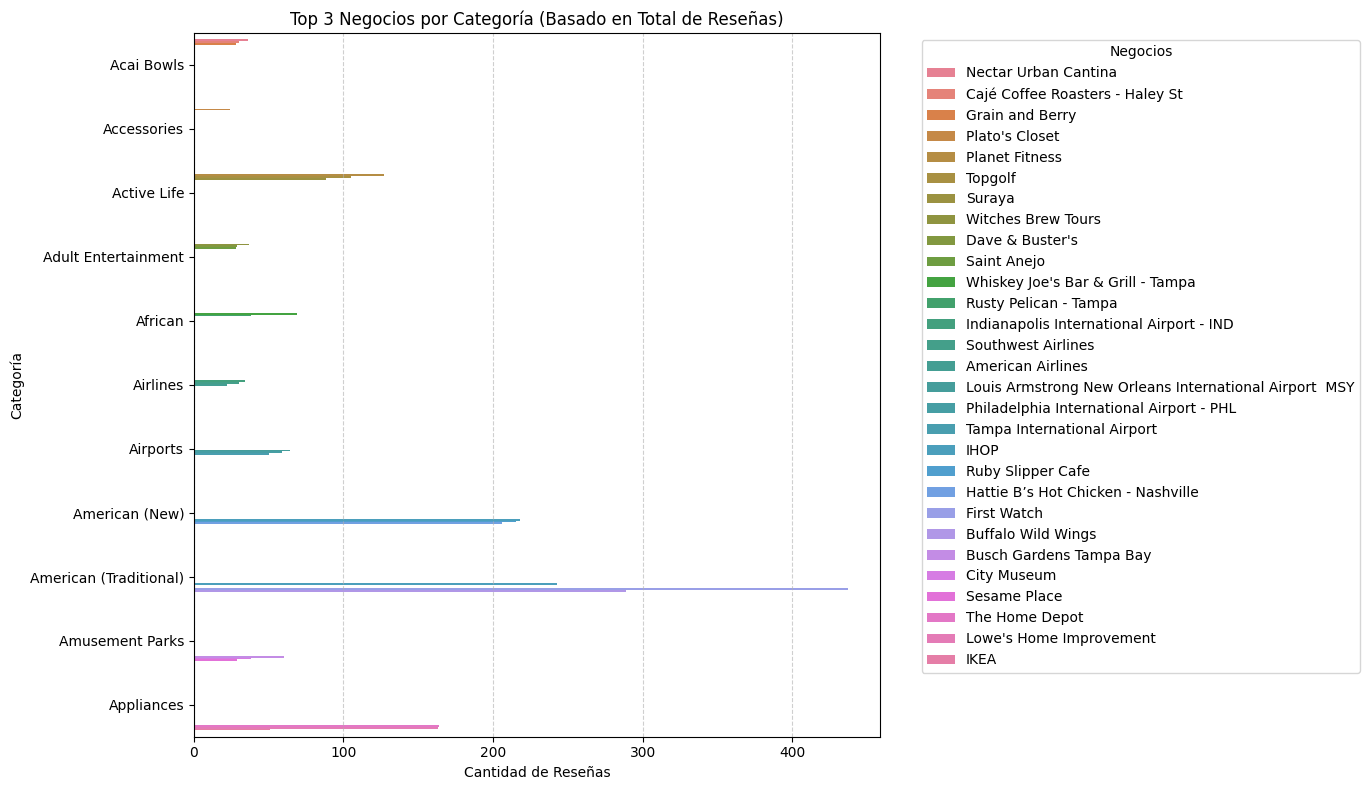

In [5]:
df = spark.sql("""
    WITH ExpandedCategories AS (
        SELECT b.business_id, b.name, TRIM(cat.category_name) AS category_name
        FROM business b
        LATERAL VIEW EXPLODE(SPLIT(b.categories, ',')) cat AS category_name
        WHERE b.categories IS NOT NULL
    ),
    BusinessStats AS (
        SELECT ec.category_name, ec.name,
               COUNT(r.review_id) AS total_reviews,
               AVG(r.stars) AS avg_rating
        FROM ExpandedCategories ec
        JOIN reviews r ON ec.business_id = r.business_id
        GROUP BY ec.category_name, ec.name
        HAVING COUNT(r.review_id) >= 20
    ),
    RankedBusinesses AS (
        SELECT category_name, name, total_reviews,
               ROUND(avg_rating, 2) AS avg_rating,
               DENSE_RANK() OVER (
                   PARTITION BY category_name
                   ORDER BY total_reviews DESC, avg_rating DESC
               ) AS market_rank
        FROM BusinessStats
    )
    SELECT category_name, market_rank, name, total_reviews, avg_rating
    FROM RankedBusinesses
    WHERE market_rank <= 3
    ORDER BY category_name ASC, market_rank ASC
""")
df.show(30, truncate=False)

pdf = df.limit(30).toPandas()
plt.figure(figsize=(14, 8))
sns.barplot(data=pdf, x='total_reviews', y='category_name', hue='name', dodge=True, errorbar=None)
plt.title('Top 3 Negocios por Categoría (Basado en Total de Reseñas)')
plt.xlabel('Cantidad de Reseñas')
plt.ylabel('Categoría')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Negocios')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(GRAFICOS, 'q05_lideres_mercado_categoria.png'), dpi=150)
plt.show()

---
## Q06 — Usuarios más influyentes por impacto de reseñas

**Pregunta ejecutiva:** ¿Qué usuarios tienen mayor influencia según volumen, utilidad y diversidad de negocios reseñados?  
**Fuentes:** `users` + `reviews`  

+----------------------+--------+------------------------+------------------+------------+---------------+---------------+
|user_id               |name    |total_reviews_realizadas|negocios_distintos|total_useful|avg_stars_given|influence_score|
+----------------------+--------+------------------------+------------------+------------+---------------+---------------+
|-G7Zkl1wIWBBmD0KRy_sCw|Gerald  |98                      |98                |4364        |3.68           |1377.8         |
|fr1Hz2acAb3OaL3l6DyKNg|Boon    |149                     |149               |2360        |3.93           |812.3          |
|WwulXySQN8t2hwqH_yWurA|Niki    |134                     |133               |1400        |4.5            |513.5          |
|qT1-N9hjbyjMW4Mvq4uU4w|Ginger  |90                      |90                |1457        |4.58           |500.1          |
|R9IJ1Byr27n6wXj3QvJ2Lg|Amy OO  |116                     |107               |1094        |4.0            |406.7          |
|2jCrH48LDG4c3ja

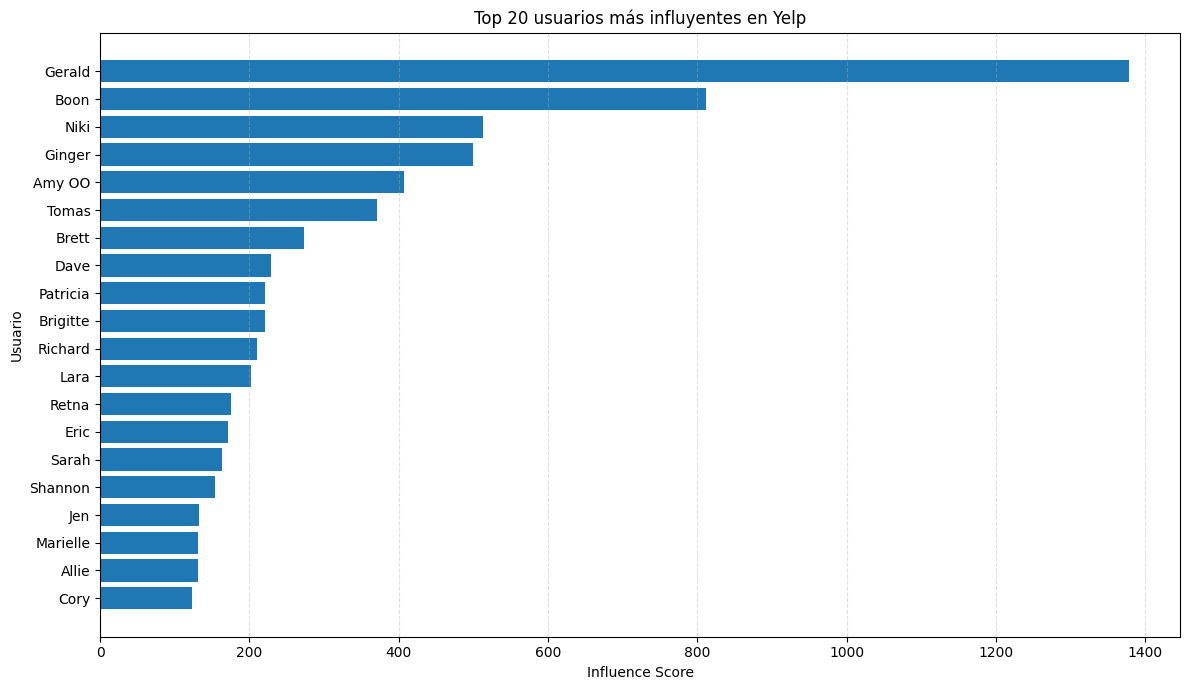

In [6]:
df = spark.sql("""
    WITH review_stats AS (
        SELECT r.user_id,
               COUNT(*) AS total_reviews_realizadas,
               COUNT(DISTINCT r.business_id) AS negocios_distintos,
               SUM(r.useful) AS total_useful,
               ROUND(AVG(r.stars), 2) AS avg_stars_given
        FROM reviews r
        GROUP BY r.user_id
    ),
    user_enriched AS (
        SELECT u.user_id, u.name,
               COALESCE(rs.total_reviews_realizadas, 0) AS total_reviews_realizadas,
               COALESCE(rs.negocios_distintos, 0) AS negocios_distintos,
               COALESCE(rs.total_useful, 0) AS total_useful,
               COALESCE(rs.avg_stars_given, u.average_stars) AS avg_stars_given
        FROM users u
        LEFT JOIN review_stats rs ON u.user_id = rs.user_id
    )
    SELECT user_id, name, total_reviews_realizadas, negocios_distintos,
           total_useful, avg_stars_given,
           ROUND(total_reviews_realizadas * 0.4 + negocios_distintos * 0.3 + total_useful * 0.3, 2) AS influence_score
    FROM user_enriched
    WHERE total_reviews_realizadas >= 50
    ORDER BY influence_score DESC
    LIMIT 20
""")
df.show(20, truncate=False)

pdf = df.toPandas()
plt.figure(figsize=(12, 7))
plt.barh(pdf['name'], pdf['influence_score'])
plt.gca().invert_yaxis()
plt.title('Top 20 usuarios más influyentes en Yelp')
plt.xlabel('Influence Score')
plt.ylabel('Usuario')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(GRAFICOS, 'q06_usuarios_mas_influyentes.png'), dpi=150)
plt.show()

---
## Q07 — Impacto de la pandemia y recuperación por estado (2018–2022)

**Pregunta ejecutiva:** ¿Qué estados fueron más golpeados por el COVID y cuáles se recuperaron más rápido?  
**Fuentes:** `reviews` + `business`  

+-----+----+-------+--------------+
|state|yr  |reviews|yoy_pct_change|
+-----+----+-------+--------------+
|AB   |2018|1087   |NULL          |
|AB   |2019|864    |-20.5         |
|AB   |2020|449    |-48.0         |
|AB   |2021|290    |-35.4         |
|AZ   |2018|4491   |NULL          |
|AZ   |2019|4483   |-0.2          |
|AZ   |2020|3056   |-31.8         |
|AZ   |2021|3312   |8.4           |
|CA   |2018|3190   |NULL          |
|CA   |2019|3000   |-6.0          |
|CA   |2020|2280   |-24.0         |
|CA   |2021|2526   |10.8          |
|DE   |2018|747    |NULL          |
|DE   |2019|764    |2.3           |
|DE   |2020|424    |-44.5         |
|DE   |2021|476    |12.3          |
|FL   |2018|13204  |NULL          |
|FL   |2019|13378  |1.3           |
|FL   |2020|9066   |-32.2         |
|FL   |2021|10594  |16.9          |
|HI   |2018|1      |NULL          |
|HI   |2019|1      |0.0           |
|ID   |2018|1877   |NULL          |
|ID   |2019|1910   |1.8           |
|ID   |2020|1402   |-26.6   

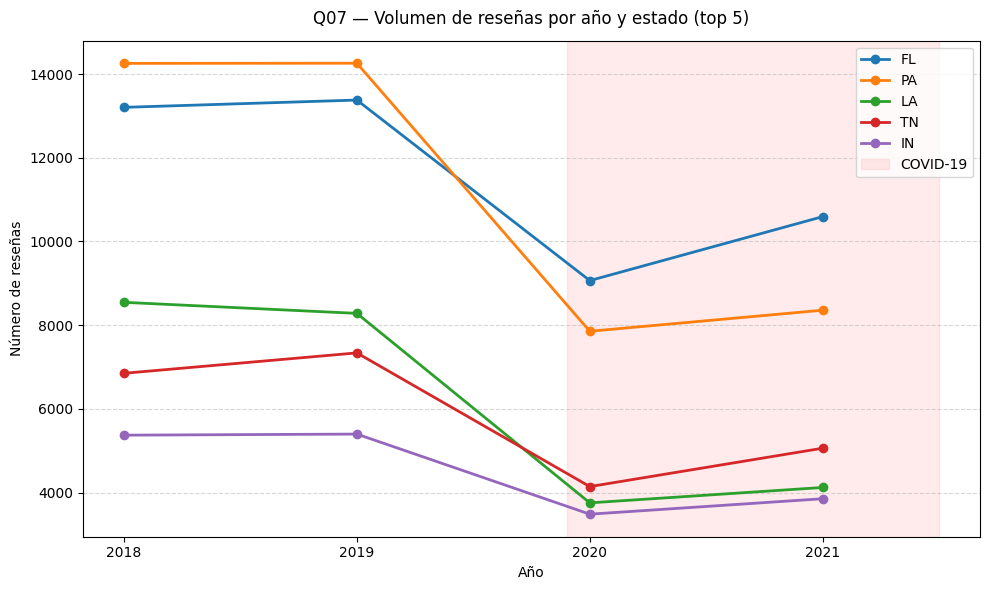

In [7]:
df = spark.sql("""
    WITH yearly AS (
        SELECT b.state,
               YEAR(CAST(r.date AS TIMESTAMP)) AS yr,
               COUNT(*) AS reviews
        FROM reviews r
        JOIN business b ON r.business_id = b.business_id
        GROUP BY b.state, YEAR(CAST(r.date AS TIMESTAMP))
    ),
    with_lag AS (
        SELECT *,
               LAG(reviews) OVER (PARTITION BY state ORDER BY yr) AS prev_reviews
        FROM yearly
    )
    SELECT state, yr, reviews,
           ROUND((reviews - prev_reviews) / prev_reviews * 100, 1) AS yoy_pct_change
    FROM with_lag
    ORDER BY state, yr
""")
df.show(50, truncate=False)

pdf = df.toPandas()
top_states = pdf.groupby('state')['reviews'].sum().nlargest(5).index.tolist()
pdf_top = pdf[pdf['state'].isin(top_states)]

fig, ax = plt.subplots(figsize=(10, 6))
for state in top_states:
    datos = pdf_top[pdf_top['state'] == state].sort_values('yr')
    ax.plot(datos['yr'], datos['reviews'], marker='o', label=state, linewidth=2)
ax.set_title('Q07 — Volumen de reseñas por año y estado (top 5)', pad=12)
ax.set_xlabel('Año')
ax.set_ylabel('Número de reseñas')
ax.set_xticks([2018, 2019, 2020, 2021, 2022])
ax.axvspan(2019.9, 2021.5, alpha=0.08, color='red', label='COVID-19')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(GRAFICOS, 'q07_pandemia_recuperacion_estado.png'), dpi=150)
plt.show()

---
## Q08 — Negocios con alto tráfico pero baja satisfacción

**Pregunta ejecutiva:** ¿Qué negocios reciben mucho tráfico pero no convierten eso en satisfacción?  
**Fuentes:** `business` + `checkins` + `reviews`  

+------------------------------------------------------+-------------+-----+--------------+------------------+----------------+----------------+---------------+
|name                                                  |city         |state|total_checkins|total_reviews_real|avg_review_stars|traffic_pct_rank|rating_pct_rank|
+------------------------------------------------------+-------------+-----+--------------+------------------+----------------+----------------+---------------+
|Philadelphia International Airport - PHL              |Philadelphia |PA   |10525         |59                |2.59            |1.0             |0.0169         |
|Louis Armstrong New Orleans International Airport  MSY|Kenner       |LA   |8061          |64                |3.19            |0.9844          |0.0156         |
|Royal House                                           |New Orleans  |LA   |7012          |161               |3.63            |0.9766          |0.1484         |
|Nashville International Airport -

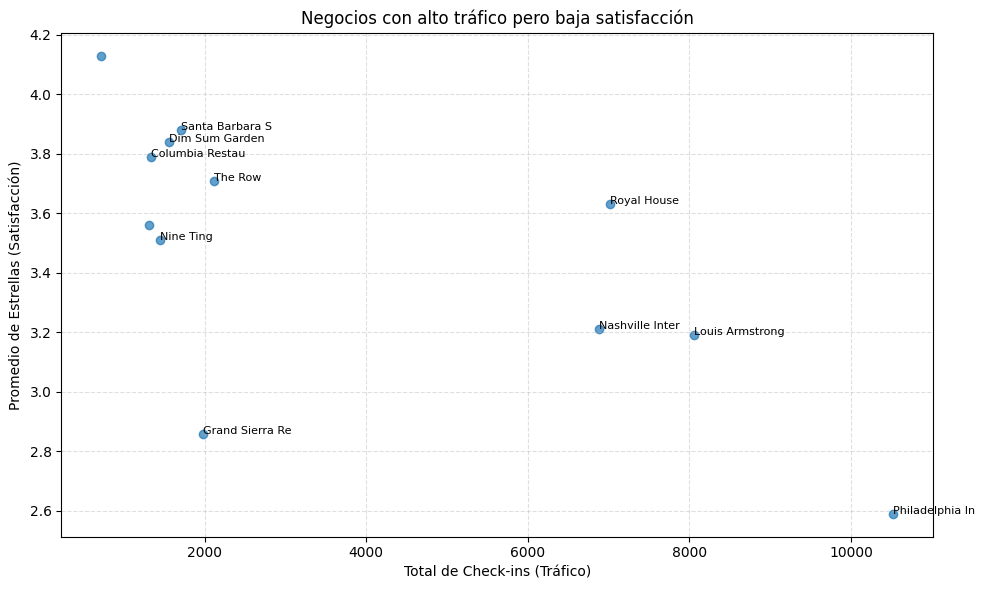

In [13]:
df = spark.sql("""
    WITH checkin_counts AS (
        SELECT business_id, COUNT(*) AS total_checkins
        FROM checkins GROUP BY business_id
    ),
    review_counts AS (
        SELECT business_id, COUNT(*) AS total_reviews,
               ROUND(AVG(stars), 2) AS avg_review_stars
        FROM reviews GROUP BY business_id
    ),
    combined AS (
        SELECT b.business_id, b.name, b.city, b.state,
               COALESCE(ch.total_checkins, 0) AS total_checkins,
               COALESCE(r.total_reviews, 0) AS total_reviews_real,
               COALESCE(r.avg_review_stars, b.stars) AS avg_review_stars
        FROM business b
        LEFT JOIN checkin_counts ch ON b.business_id = ch.business_id
        LEFT JOIN review_counts r   ON b.business_id = r.business_id
    ),
    ranked AS (
        SELECT *,
               ROUND(PERCENT_RANK() OVER (PARTITION BY state ORDER BY total_checkins), 4) AS traffic_pct_rank,
               ROUND(PERCENT_RANK() OVER (PARTITION BY state ORDER BY avg_review_stars), 4) AS rating_pct_rank
        FROM combined
        WHERE total_checkins > 0 AND total_reviews_real >= 30
    )
    SELECT name, city, state, total_checkins, total_reviews_real,
           avg_review_stars, traffic_pct_rank, rating_pct_rank
    FROM ranked
    WHERE traffic_pct_rank >= 0.90 AND rating_pct_rank <= 0.25
    ORDER BY total_checkins DESC, avg_review_stars ASC
    LIMIT 30
""")
df.show(30, truncate=False)

pdf = df.toPandas()
plt.figure(figsize=(10, 6))
plt.scatter(pdf['total_checkins'], pdf['avg_review_stars'], alpha=0.7)
for i, row in pdf.head(10).iterrows():
    plt.text(row['total_checkins'], row['avg_review_stars'], row['name'][:15], fontsize=8)
plt.title('Negocios con alto tráfico pero baja satisfacción')
plt.xlabel('Total de Check-ins (Tráfico)')
plt.ylabel('Promedio de Estrellas (Satisfacción)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(GRAFICOS, 'q08_alto_trafico_baja_satisfaccion.png'), dpi=150)
plt.show()

---
## Q09 — Tendencias de calidad y brecha de rendimiento mensual

**Pregunta ejecutiva:** ¿Qué negocios muestran las caídas más pronunciadas en calidad respecto a su propia tendencia reciente?  
**Fuentes:** `reviews` + `business`  

+--------------------------------------+-------------------+--------------------+------------------+---------------+
|name                                  |review_month       |current_month_rating|rolling_avg_rating|performance_gap|
+--------------------------------------+-------------------+--------------------+------------------+---------------+
|I Like To Move It                     |2020-08-01 00:00:00|1.8                 |3.93              |-2.13          |
|Whiskey Joe's Bar & Grill - Tampa     |2021-12-01 00:00:00|1.8                 |3.49              |-1.69          |
|White Limozeen                        |2021-07-01 00:00:00|2.67                |4.22              |-1.56          |
|Finney's Crafthouse                   |2019-06-01 00:00:00|2.4                 |3.91              |-1.51          |
|The Ritz-Carlton Bacara, Santa Barbara|2020-08-01 00:00:00|1.67                |3.11              |-1.44          |
|AMC 309 Cinema 9                      |2018-05-01 00:00:00|2.2 

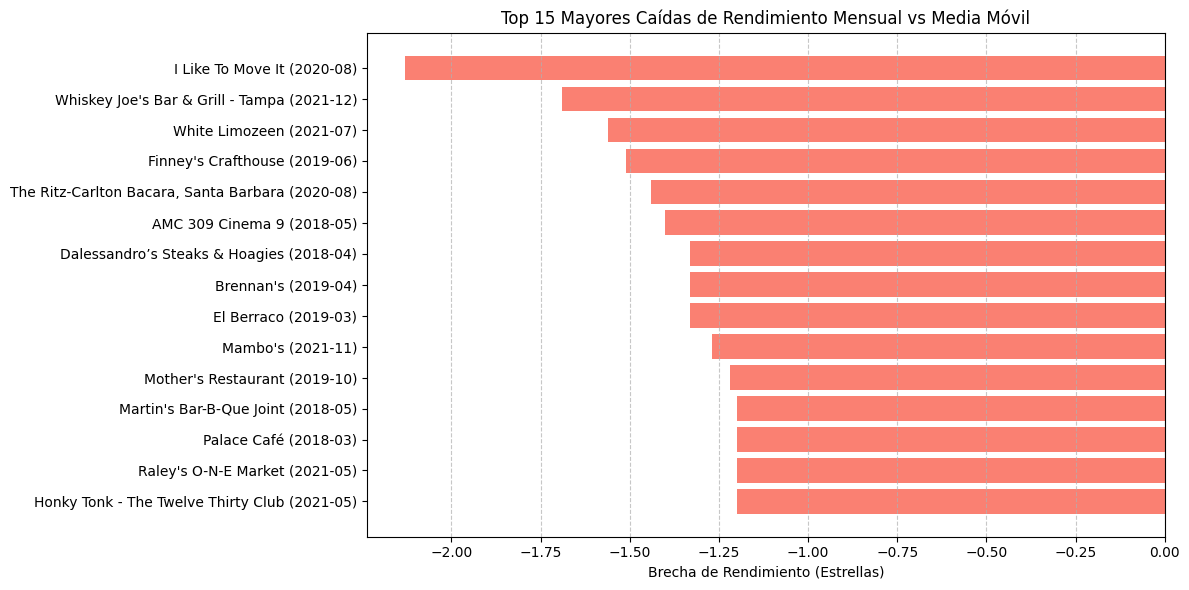

In [11]:
df = spark.sql("""
    WITH ResenasMensuales AS (
        SELECT c.business_id, c.name,
               DATE_TRUNC('month', r.date) AS review_month,
               AVG(r.stars) AS monthly_avg_stars,
               COUNT(r.review_id) AS total_reviews_month
        FROM reviews r
        JOIN business c ON r.business_id = c.business_id
        GROUP BY 1, 2, 3
    ),
    MediaMovil AS (
        SELECT business_id, name, review_month, monthly_avg_stars, total_reviews_month,
               AVG(monthly_avg_stars) OVER (
                   PARTITION BY business_id
                   ORDER BY review_month
                   ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
               ) AS rolling_3m_avg
        FROM ResenasMensuales
    )
    SELECT name, review_month,
           ROUND(monthly_avg_stars, 2) AS current_month_rating,
           ROUND(rolling_3m_avg, 2) AS rolling_avg_rating,
           ROUND(monthly_avg_stars - rolling_3m_avg, 2) AS performance_gap
    FROM MediaMovil
    WHERE total_reviews_month >= 5
    ORDER BY performance_gap ASC
    LIMIT 15
""")
df.show(15, truncate=False)

pdf = df.withColumn('review_month', F.col('review_month').cast('string')).toPandas()
pdf['review_month'] = pd.to_datetime(pdf['review_month'])

plt.figure(figsize=(12, 6))
plt.barh(
    pdf['name'] + ' (' + pdf['review_month'].dt.strftime('%Y-%m') + ')',
    pdf['performance_gap'],
    color='salmon',
)
plt.xlabel('Brecha de Rendimiento (Estrellas)')
plt.title('Top 15 Mayores Caídas de Rendimiento Mensual vs Media Móvil')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(GRAFICOS, 'q09_brecha_rendimiento_mensual.png'), dpi=150)
plt.show()

---
## Q10 — Clustering de negocios (segmentación)

**Pregunta ejecutiva:** ¿Existen segmentos naturales de negocios según popularidad, calidad y tráfico?  
**Fuentes:** `business` + `checkins`  

Centroides de clusters:
[[-1.19859838e+00 -1.50920447e-01 -1.26860848e-01]
 [ 5.85334243e-01 -5.48865428e-02 -4.54485940e-02]
 [ 2.30604450e-01  2.99254459e+01  6.34726126e+01]
 [ 4.02566283e-01  4.96706032e+00  3.93326381e+00]]

Promedios por cluster:
            stars  review_count  total_checkins
cluster                                        
0        2.428788     26.587117        8.831391
1        4.167089     38.199218       16.573606
2        3.821429   3669.428571     6065.285714
3        3.989217    645.787141      394.976038


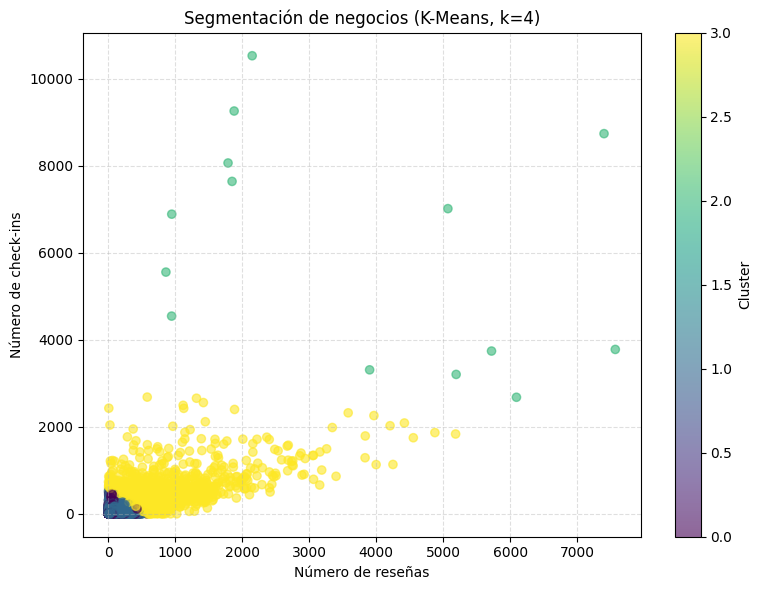

In [10]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = spark.sql("""
    WITH checkins_count AS (
        SELECT business_id, COUNT(*) AS total_checkins
        FROM checkins GROUP BY business_id
    )
    SELECT b.name, b.stars, b.review_count,
           COALESCE(c.total_checkins, 0) AS total_checkins
    FROM business b
    LEFT JOIN checkins_count c ON b.business_id = c.business_id
    WHERE b.review_count IS NOT NULL AND b.stars IS NOT NULL
""")

pdf = df.toPandas()
X = pdf[['stars', 'review_count', 'total_checkins']]
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
pdf['cluster'] = kmeans.fit_predict(X_scaled)

print('Centroides de clusters:')
print(kmeans.cluster_centers_)
print('\nPromedios por cluster:')
print(pdf.groupby('cluster')[['stars', 'review_count', 'total_checkins']].mean())

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    pdf['review_count'], pdf['total_checkins'],
    c=pdf['cluster'], cmap='viridis', alpha=0.6
)
plt.xlabel('Número de reseñas')
plt.ylabel('Número de check-ins')
plt.title('Segmentación de negocios (K-Means, k=4)')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(GRAFICOS, 'q10_clustering.png'), dpi=200)
plt.show()